In [153]:
# ============================================================
# 1. LOAD DATASET
# ============================================================

import pandas as pd

df = pd.read_csv("simulated_iiot_dataset.csv")

print("First 5 rows:")
print(df.head())

First 5 rows:
   temperature  vibration   pressure   humidity  rotation_speed     voltage  \
0    77.483571   0.639936  27.974465  30.460962     1456.825320  215.762403   
1    74.308678   0.592463  29.566444  35.698075     1498.439826  215.465859   
2    78.238443   0.505963  27.622740  37.931972     1500.900844  202.043568   
3    82.615149   0.435306  29.076115  49.438438     1523.631517  216.699098   
4    73.829233   0.569822  24.319156  42.782766     1431.657082  227.328291   

    current  oil_level       load  motor_temperature  gearbox_temperature  \
0  4.442959  73.925925  79.669747          63.827011            61.607526   
1  4.684535  61.111595  74.963497          65.367064            63.472503   
2  4.528970  73.573728  78.276250          62.493450            62.013095   
3  4.726002  68.831380  87.147317          50.287512            65.552090   
4  4.892925  73.537289  92.778567          59.222888            70.985893   

   sound_level    fan_speed  reactive_power  act

In [154]:
# ============================================================
# 2. DATASET INFORMATION
# ============================================================

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())



Dataset shape:
(1000, 17)

Column names:
Index(['temperature', 'vibration', 'pressure', 'humidity', 'rotation_speed',
       'voltage', 'current', 'oil_level', 'load', 'motor_temperature',
       'gearbox_temperature', 'sound_level', 'fan_speed', 'reactive_power',
       'active_power', 'machine_failure', 'timestamp'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   temperature          1000 non-null   float64
 1   vibration            1000 non-null   float64
 2   pressure             1000 non-null   float64
 3   humidity             1000 non-null   float64
 4   rotation_speed       1000 non-null   float64
 5   voltage              1000 non-null   float64
 6   current              1000 non-null   float64
 7   oil_level            1000 non-null   float64
 8   load                 10

In [155]:
# ============================================================
# 3. MACHINE FAILURE ANALYSIS
# ============================================================

print("\nMachine Failure Counts:")
print(df["machine_failure"].value_counts())

print("\nMachine Failure Percentages:")
print(df["machine_failure"].value_counts(normalize=True) * 100)



Machine Failure Counts:
machine_failure
0    838
1    162
Name: count, dtype: int64

Machine Failure Percentages:
machine_failure
0    83.8
1    16.2
Name: proportion, dtype: float64


In [156]:
# ============================================================
# 4. STATISTICAL SUMMARY
# ============================================================

print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       temperature    vibration     pressure     humidity  rotation_speed  \
count  1000.000000  1000.000000  1000.000000  1000.000000     1000.000000   
mean     75.096660     0.507084    30.017503    39.906404     1497.536318   
std       4.896080     0.099745     2.950363     5.135663       49.619011   
min      58.793663     0.205961    20.941464    25.352757     1341.164809   
25%      71.762048     0.439376    28.056001    36.312898     1465.869752   
50%      75.126503     0.506308    29.999248    40.000923     1499.087900   
75%      78.239719     0.572888    31.982746    43.334727     1531.956157   
max      94.263657     0.819311    41.778713    56.215465     1655.645510   

           voltage      current    oil_level         load  motor_temperature  \
count  1000.000000  1000.000000  1000.000000  1000.000000        1000.000000   
mean    219.532624     4.985922    70.096085    80.183418          59.939829   
std      10.073892     0.512502     5.208700

In [157]:
# ============================================================
# 5. GRAPHICAL ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

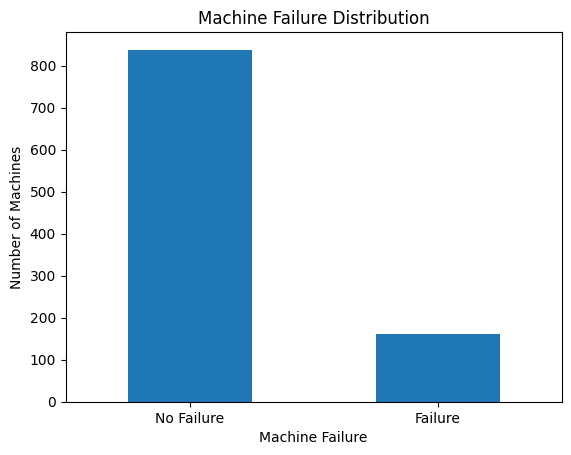

In [158]:
# ------------------------------
# Machine Failure Distribution
# ------------------------------

df["machine_failure"].value_counts().plot(kind="bar")

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Number of Machines")
plt.xticks([0, 1], ["No Failure", "Failure"], rotation=0)

plt.show()


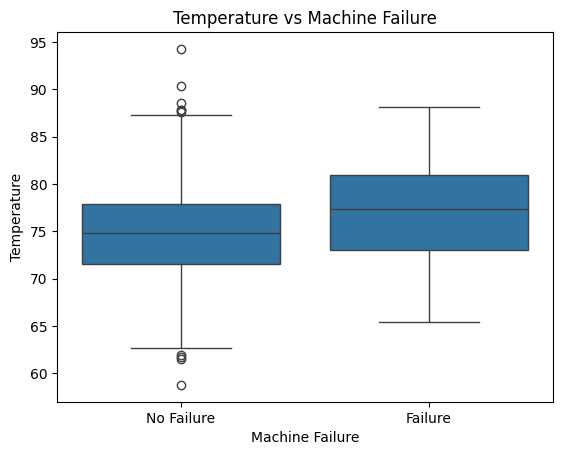

In [159]:
# ------------------------------
# Temperature vs Failure
# ------------------------------

sns.boxplot(
    x="machine_failure",
    y="temperature",
    data=df
)

plt.title("Temperature vs Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Temperature")

plt.xticks([0, 1], ["No Failure", "Failure"])

plt.show()

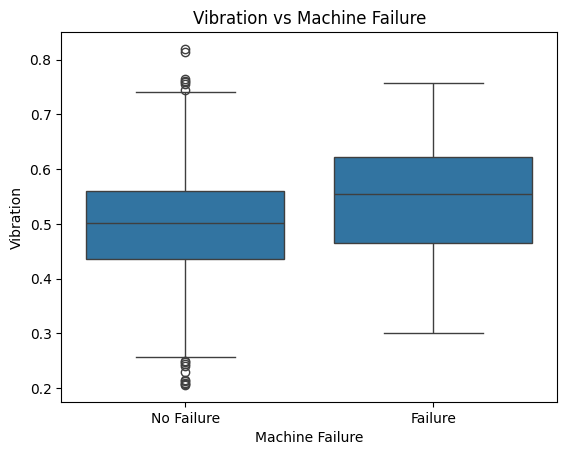

In [160]:
# ------------------------------
# Vibration vs Failure
# ------------------------------

sns.boxplot(
    x="machine_failure",
    y="vibration",
    data=df
)

plt.title("Vibration vs Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Vibration")

plt.xticks([0, 1], ["No Failure", "Failure"])

plt.show()

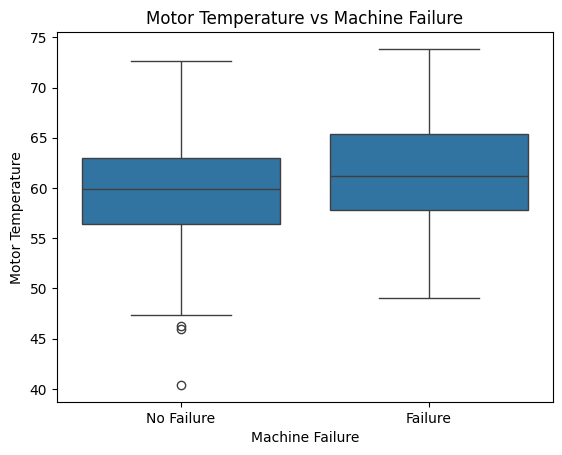

In [161]:
# ------------------------------
# Motor Temperature vs Failure
# ------------------------------

sns.boxplot(
    x="machine_failure",
    y="motor_temperature",
    data=df
)

plt.title("Motor Temperature vs Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Motor Temperature")

plt.xticks([0, 1], ["No Failure", "Failure"])

plt.show()

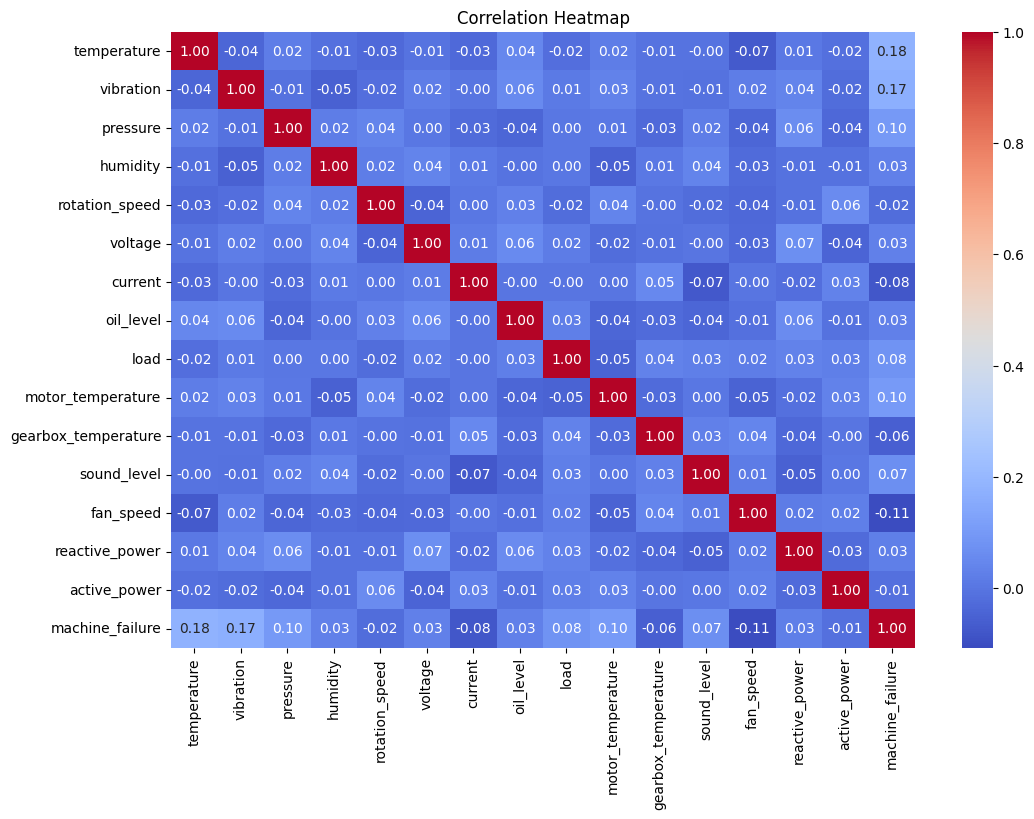

In [162]:
# ============================================================
# 6. CORRELATION ANALYSIS
# ============================================================

plt.figure(figsize=(12, 8))

correlation = df.drop(columns=["timestamp"]).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [163]:
# ============================================================
# 7. DATA PREPARATION FOR MACHINE LEARNING
# ============================================================

# Convert timestamp into datetime format

df["timestamp"] = pd.to_datetime(df["timestamp"])


# Extract useful time features

df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["day_of_week"] = df["timestamp"].dt.dayofweek


# Remove original timestamp

df = df.drop(columns=["timestamp"])


# Separate features and target

X = df.drop(columns=["machine_failure"])

y = df["machine_failure"]


print("\nX shape:")
print(X.shape)

print("\ny shape:")
print(y.shape)



X shape:
(1000, 19)

y shape:
(1000,)


In [164]:
# ============================================================
# 8. TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining data:")
print(X_train.shape)

print("Testing data:")
print(X_test.shape)


Training data:
(800, 19)
Testing data:
(200, 19)


In [165]:
# ============================================================
# 9. IMPORT EVALUATION METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [166]:
# ============================================================
# 10. LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)


# Train model

model.fit(X_train, y_train)

print("\nLogistic Regression training completed!")


# Make predictions

y_pred = model.predict(X_test)


# Evaluation

accuracy = accuracy_score(y_test, y_pred)

print("\nLogistic Regression Accuracy:")
print(accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Logistic Regression training completed!

Logistic Regression Accuracy:
0.845

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       168
           1       0.67      0.06      0.11        32

    accuracy                           0.84       200
   macro avg       0.76      0.53      0.51       200
weighted avg       0.82      0.84      0.79       200


Confusion Matrix:
[[167   1]
 [ 30   2]]


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [167]:
# ============================================================
# 11. FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


# Fit scaler using training data
# Then transform training data

X_train_scaled = scaler.fit_transform(X_train)


# Transform test data using the same scaler

X_test_scaled = scaler.transform(X_test)


print("\nFeature scaling completed!")


Feature scaling completed!


In [168]:
# ============================================================
# 12. SCALED LOGISTIC REGRESSION
# ============================================================

scaled_model = LogisticRegression(max_iter=1000)


# Train scaled model

scaled_model.fit(X_train_scaled, y_train)

print("\nScaled Logistic Regression training completed!")


# Make predictions

y_pred_scaled = scaled_model.predict(X_test_scaled)


# Evaluation

accuracy_scaled = accuracy_score(
    y_test,
    y_pred_scaled
)

print("\nScaled Logistic Regression Accuracy:")
print(accuracy_scaled)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_scaled
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_scaled
))


Scaled Logistic Regression training completed!

Scaled Logistic Regression Accuracy:
0.835

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       168
           1       0.43      0.09      0.15        32

    accuracy                           0.83       200
   macro avg       0.64      0.53      0.53       200
weighted avg       0.78      0.83      0.79       200


Confusion Matrix:
[[164   4]
 [ 29   3]]


In [169]:
# ============================================================
# 13.Balanced DECISION TREE
# ============================================================

from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

# Train model

tree_model.fit(X_train, y_train)

print("\nDecision Tree training completed!")

# Make predictions

y_pred_tree = tree_model.predict(X_test)

# Evaluation

tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

print("\nDecision Tree Accuracy:")
print(tree_accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tree
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_tree
))


Decision Tree training completed!

Decision Tree Accuracy:
0.73

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       168
           1       0.19      0.22      0.21        32

    accuracy                           0.73       200
   macro avg       0.52      0.52      0.52       200
weighted avg       0.74      0.73      0.74       200


Confusion Matrix:
[[139  29]
 [ 25   7]]


In [170]:
# ============================================================
# 14. RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)


# Train model

rf_model.fit(X_train, y_train)

print("\nRandom Forest training completed!")


# Make predictions

y_pred_rf = rf_model.predict(X_test)


# Evaluation

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("\nRandom Forest Accuracy:")
print(rf_accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_rf
))


Random Forest training completed!

Random Forest Accuracy:
0.85

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       168
           1       1.00      0.06      0.12        32

    accuracy                           0.85       200
   macro avg       0.92      0.53      0.52       200
weighted avg       0.87      0.85      0.79       200


Confusion Matrix:
[[168   0]
 [ 30   2]]


In [171]:
# ============================================================
# IMPROVED XGBOOST
# ============================================================

from xgboost import XGBClassifier

# Calculate class imbalance
negative = y_train.value_counts()[0]
positive = y_train.value_counts()[1]

scale_pos_weight = negative / positive

print("\nScale Pos Weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

# Train model
xgb_model.fit(X_train, y_train)

print("\nImproved XGBoost training completed!")

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# ============================================================
# EVALUATION
# ============================================================

xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

print("\nImproved XGBoost Accuracy:")
print(xgb_accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_xgb
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_xgb
))


Scale Pos Weight: 5.153846153846154

Improved XGBoost training completed!

Improved XGBoost Accuracy:
0.83

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       168
           1       0.46      0.34      0.39        32

    accuracy                           0.83       200
   macro avg       0.67      0.63      0.65       200
weighted avg       0.81      0.83      0.82       200


Confusion Matrix:
[[155  13]
 [ 21  11]]


In [172]:
# ============================================================
# 16. CHECK TRAINING AND TESTING CLASS DISTRIBUTION
# ============================================================

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())


Training class distribution:
machine_failure
0    670
1    130
Name: count, dtype: int64

Testing class distribution:
machine_failure
0    168
1     32
Name: count, dtype: int64


In [173]:
# ============================================================
# 17. MODEL COMPARISON
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {
    "Logistic Regression": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],

    "Scaled Logistic Regression": [
        accuracy_score(y_test, y_pred_scaled),
        precision_score(y_test, y_pred_scaled),
        recall_score(y_test, y_pred_scaled),
        f1_score(y_test, y_pred_scaled)
    ],

    "Decision Tree": [
        accuracy_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_tree)
    ],

    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf)
    ],

    "XGBoost": [
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb)
    ]
}

comparison = pd.DataFrame(
    results,
    index=["Accuracy", "Precision", "Recall", "F1-Score"]
)

print("\n================ MODEL COMPARISON ================")
print(comparison.round(3))


================ MODEL COMPARISON ================
           Logistic Regression  Scaled Logistic Regression  Decision Tree  \
Accuracy                 0.845                       0.835          0.730   
Precision                0.667                       0.429          0.194   
Recall                   0.062                       0.094          0.219   
F1-Score                 0.114                       0.154          0.206   

           Random Forest  XGBoost  
Accuracy           0.850    0.830  
Precision          1.000    0.458  
Recall             0.062    0.344  
F1-Score           0.118    0.393  


In [174]:
# ============================================================
# 18. FAILURE PROBABILITY
# ============================================================

# Get probability of machine failure
failure_probability = xgb_model.predict_proba(X_test)[:, 1]

print("\nFirst 10 Failure Probabilities:")

for i in range(10):
    print(
        f"Machine {i + 1}: "
        f"{failure_probability[i] * 100:.2f}%"
    )


First 10 Failure Probabilities:
Machine 1: 23.93%
Machine 2: 44.36%
Machine 3: 33.32%
Machine 4: 3.53%
Machine 5: 1.27%
Machine 6: 0.26%
Machine 7: 45.22%
Machine 8: 80.76%
Machine 9: 9.76%
Machine 10: 29.41%


In [175]:
# ============================================================
# 19. RISK LEVEL
# ============================================================

def get_risk_level(probability):

    if probability < 0.30:
        return "LOW"

    elif probability < 0.60:
        return "MEDIUM"

    else:
        return "HIGH"


print("\nMachine Risk Levels:")

for i in range(10):

    probability = failure_probability[i]

    risk = get_risk_level(probability)

    print(
        f"Machine {i + 1}: "
        f"{probability * 100:.2f}% "
        f"-> {risk} RISK"
    )


Machine Risk Levels:
Machine 1: 23.93% -> LOW RISK
Machine 2: 44.36% -> MEDIUM RISK
Machine 3: 33.32% -> MEDIUM RISK
Machine 4: 3.53% -> LOW RISK
Machine 5: 1.27% -> LOW RISK
Machine 6: 0.26% -> LOW RISK
Machine 7: 45.22% -> MEDIUM RISK
Machine 8: 80.76% -> HIGH RISK
Machine 9: 9.76% -> LOW RISK
Machine 10: 29.41% -> LOW RISK


In [176]:
# ============================================================
# 20. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

print("\nFeature Importance:")

print(feature_importance)


Feature Importance:
temperature            0.094081
vibration              0.093088
pressure               0.090510
motor_temperature      0.084261
load                   0.072981
current                0.056520
oil_level              0.049062
fan_speed              0.048348
rotation_speed         0.047813
active_power           0.044425
sound_level            0.043877
gearbox_temperature    0.042423
hour                   0.039709
day                    0.038338
reactive_power         0.036128
day_of_week            0.036126
humidity               0.035955
voltage                0.026091
month                  0.020265
dtype: float32


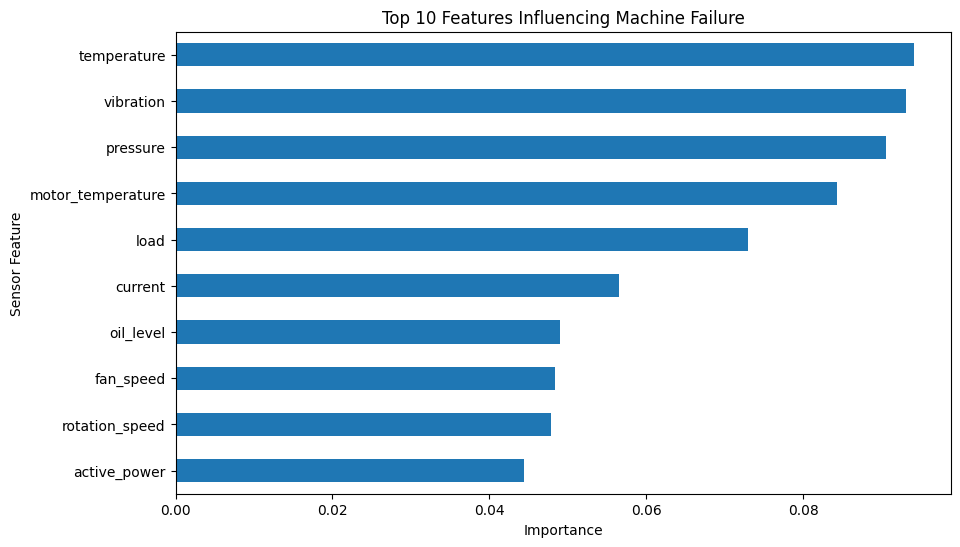

In [177]:
# ============================================================
# 21. FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Features Influencing Machine Failure")
plt.xlabel("Importance")
plt.ylabel("Sensor Feature")

plt.show()

In [178]:
# ============================================================
# 22. MAINTENANCE RECOMMENDATION
# ============================================================

def get_maintenance_recommendation(risk):

    if risk == "LOW":
        return "Continue normal monitoring"

    elif risk == "MEDIUM":
        return "Schedule maintenance inspection"

    else:
        return "Immediate maintenance inspection"


print("\nMaintenance Recommendations:")

for i in range(10):

    probability = failure_probability[i]

    risk = get_risk_level(probability)

    recommendation = get_maintenance_recommendation(risk)

    print(
        f"Machine {i + 1}: "
        f"{risk} RISK -> "
        f"{recommendation}"
    )


Maintenance Recommendations:
Machine 1: LOW RISK -> Continue normal monitoring
Machine 2: MEDIUM RISK -> Schedule maintenance inspection
Machine 3: MEDIUM RISK -> Schedule maintenance inspection
Machine 4: LOW RISK -> Continue normal monitoring
Machine 5: LOW RISK -> Continue normal monitoring
Machine 6: LOW RISK -> Continue normal monitoring
Machine 7: MEDIUM RISK -> Schedule maintenance inspection
Machine 8: HIGH RISK -> Immediate maintenance inspection
Machine 9: LOW RISK -> Continue normal monitoring
Machine 10: LOW RISK -> Continue normal monitoring


In [179]:
# ============================================================
# 23. MACHINE FAILURE PREDICTION FUNCTION
# ============================================================

def predict_machine(sensor_data):

    # Convert sensor data into DataFrame
    input_data = pd.DataFrame([sensor_data])

    # Get failure probability
    probability = xgb_model.predict_proba(input_data)[0][1]

    # Get risk level
    risk = get_risk_level(probability)

    # Get maintenance recommendation
    recommendation = get_maintenance_recommendation(risk)

    return probability, risk, recommendation

In [180]:
# ============================================================
# 24. TEST PREDICTION FUNCTION
# ============================================================

sample_machine = X_test.iloc[0].to_dict()

probability, risk, recommendation = predict_machine(
    sample_machine
)

print("\n================ MACHINE PREDICTION ================")

print(
    f"Failure Probability: {probability * 100:.2f}%"
)

print(
    f"Risk Level: {risk}"
)

print(
    f"Recommendation: {recommendation}"
)


================ MACHINE PREDICTION ================
Failure Probability: 23.93%
Risk Level: LOW
Recommendation: Continue normal monitoring


In [181]:
# ============================================================
# 25. THRESHOLD TUNING
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import numpy as np

# Split training data into training and validation data
X_train_part, X_validation, y_train_part, y_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Create a temporary XGBoost model
tuning_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

# Train temporary model
tuning_model.fit(
    X_train_part,
    y_train_part
)

# Get failure probabilities on validation data
validation_probability = tuning_model.predict_proba(
    X_validation
)[:, 1]


# ============================================================
# 26.FIND BEST THRESHOLD
# ============================================================

best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.10, 0.91, 0.01):

    validation_prediction = (
        validation_probability >= threshold
    ).astype(int)

    current_f1 = f1_score(
        y_validation,
        validation_prediction
    )

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold


print("\n================ THRESHOLD TUNING ================")

print(
    f"Best Threshold: {best_threshold:.2f}"
)

print(
    f"Validation F1-Score: {best_f1:.3f}"
)


================ THRESHOLD TUNING ================
Best Threshold: 0.34
Validation F1-Score: 0.533


In [182]:
# ============================================================
# 27. FINAL XGBOOST WITH TUNED THRESHOLD
# ============================================================

# Get failure probabilities from our final XGBoost model
test_probability = xgb_model.predict_proba(
    X_test
)[:, 1]

# Apply tuned threshold
y_pred_tuned = (
    test_probability >= best_threshold
).astype(int)


# ============================================================
# EVALUATION
# ============================================================

print("\n================ TUNED XGBOOST ================")

print(
    "\nAccuracy:",
    accuracy_score(y_test, y_pred_tuned)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_tuned
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred_tuned
    )
)


================ TUNED XGBOOST ================

Accuracy: 0.765

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.82      0.85       168
           1       0.33      0.47      0.39        32

    accuracy                           0.77       200
   macro avg       0.61      0.65      0.62       200
weighted avg       0.80      0.77      0.78       200


Confusion Matrix:
[[138  30]
 [ 17  15]]



================ ROC-AUC ================
ROC-AUC Score: 0.814


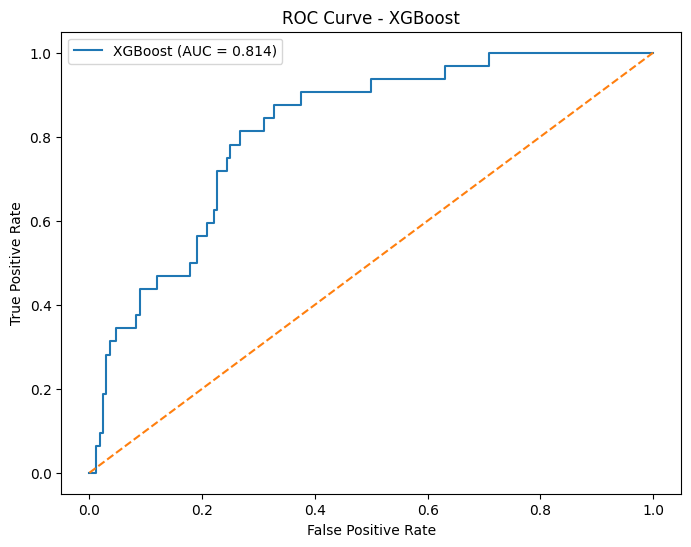

In [183]:
# ============================================================
# 28. ROC-AUC EVALUATION
# ============================================================

from sklearn.metrics import roc_auc_score, roc_curve

# Calculate ROC-AUC
roc_auc = roc_auc_score(
    y_test,
    test_probability
)

print("\n================ ROC-AUC ================")

print("ROC-AUC Score:", round(roc_auc, 3))


# Create ROC curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    test_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend()

plt.show()


================ PRECISION-RECALL ================
Average Precision Score: 0.423


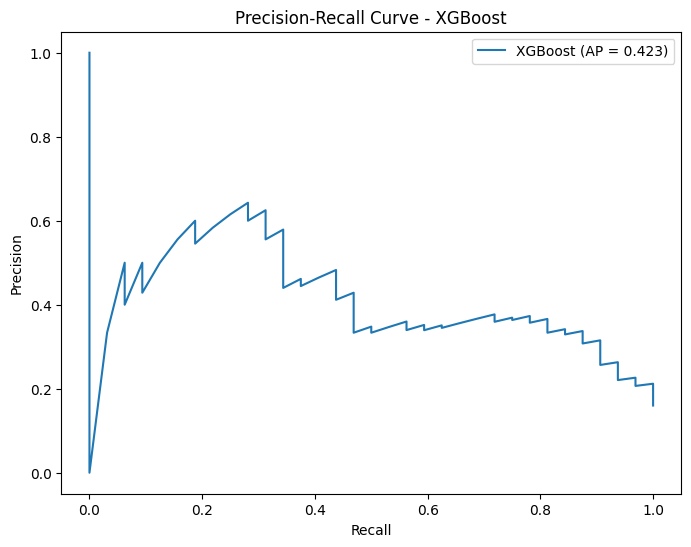

In [184]:
# ============================================================
# 29. PRECISION-RECALL CURVE
# ============================================================

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    test_probability
)

average_precision = average_precision_score(
    y_test,
    test_probability
)

print("\n================ PRECISION-RECALL ================")

print(
    "Average Precision Score:",
    round(average_precision, 3)
)


plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"XGBoost (AP = {average_precision:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve - XGBoost")

plt.legend()

plt.show()

In [185]:
# ============================================================
# 30. FINAL PREDICTION PIPELINE
# ============================================================

def final_machine_prediction(sensor_data):

    # Convert input into DataFrame
    input_data = pd.DataFrame([sensor_data])

    # Get failure probability
    probability = xgb_model.predict_proba(
        input_data
    )[0][1]

    # Use tuned threshold
    if probability >= best_threshold:
        prediction = "FAILURE"
    else:
        prediction = "NO FAILURE"

    # Risk level
    risk = get_risk_level(probability)

    # Maintenance recommendation
    recommendation = get_maintenance_recommendation(risk)

    # Find important features
    importance = pd.Series(
        xgb_model.feature_importances_,
        index=X_train.columns
    )

    top_features = importance.sort_values(
        ascending=False
    ).head(5)

    return {
        "failure_probability": probability,
        "prediction": prediction,
        "risk_level": risk,
        "top_features": top_features,
        "recommendation": recommendation
    }

In [186]:
# ============================================================
# 31. TEST FINAL PIPELINE
# ============================================================

sample_machine = X_test.iloc[0].to_dict()

result = final_machine_prediction(
    sample_machine
)

print("\n================ FINAL MACHINE PREDICTION ================")

print(
    f"Failure Probability: "
    f"{result['failure_probability'] * 100:.2f}%"
)

print(
    f"Prediction: "
    f"{result['prediction']}"
)

print(
    f"Risk Level: "
    f"{result['risk_level']}"
)

print("\nTop Important Features:")

print(result["top_features"])

print(
    f"\nMaintenance Recommendation: "
    f"{result['recommendation']}"
)


================ FINAL MACHINE PREDICTION ================
Failure Probability: 23.93%
Prediction: NO FAILURE
Risk Level: LOW

Top Important Features:
temperature          0.094081
vibration            0.093088
pressure             0.090510
motor_temperature    0.084261
load                 0.072981
dtype: float32

Maintenance Recommendation: Continue normal monitoring


In [187]:
# ============================================================
# 32. SAVE FINAL MODEL
# ============================================================

import joblib

joblib.dump(
    xgb_model,
    "predictive_maintenance_model.pkl"
)

joblib.dump(
    best_threshold,
    "failure_threshold.pkl"
)

print("\nFinal XGBoost model saved successfully!")
print("Final threshold saved successfully!")


Final XGBoost model saved successfully!
Final threshold saved successfully!


In [188]:
# ============================================================
# SECTION 33: SMOTE FOR CLASS IMBALANCE
# ============================================================

from imblearn.over_sampling import SMOTE

print("\n" + "="*60)
print("SMOTE CLASS BALANCING")
print("="*60)

# Check class distribution before SMOTE
print("\nClass distribution BEFORE SMOTE:")
print(y_train.value_counts())

# Create SMOTE object
smote = SMOTE(random_state=42)

# Apply SMOTE ONLY to training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Check class distribution after SMOTE
print("\nClass distribution AFTER SMOTE:")
print(y_train_smote.value_counts())

print("\nTraining data before SMOTE:", X_train.shape)
print("Training data after SMOTE:", X_train_smote.shape)





SMOTE CLASS BALANCING

Class distribution BEFORE SMOTE:
machine_failure
0    670
1    130
Name: count, dtype: int64

Class distribution AFTER SMOTE:
machine_failure
0    670
1    670
Name: count, dtype: int64

Training data before SMOTE: (800, 19)
Training data after SMOTE: (1340, 19)


In [189]:
# ============================================================
# SECTION 34: XGBOOST WITH SMOTE
# ============================================================

print("\n" + "="*60)
print("TRAINING XGBOOST WITH SMOTE")
print("="*60)

# Create XGBoost model
# NOTE: scale_pos_weight is NOT used here
# because SMOTE already balances the training data.

xgb_smote = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

# Train model using SMOTE data
xgb_smote.fit(
    X_train_smote,
    y_train_smote
)

print("\nSMOTE XGBoost training completed.")


TRAINING XGBOOST WITH SMOTE

SMOTE XGBoost training completed.


In [190]:
# ============================================================
# SECTION 35: EVALUATE SMOTE XGBOOST
# ============================================================

print("\n" + "="*60)
print("SMOTE XGBOOST - DEFAULT THRESHOLD")
print("="*60)

# Predict test data
y_pred_smote = xgb_smote.predict(X_test)

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))


SMOTE XGBOOST - DEFAULT THRESHOLD

Confusion Matrix:
[[149  19]
 [ 21  11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       168
           1       0.37      0.34      0.35        32

    accuracy                           0.80       200
   macro avg       0.62      0.62      0.62       200
weighted avg       0.79      0.80      0.80       200



In [191]:
# ============================================================
# SECTION 36: SMOTE FAILURE PROBABILITY
# ============================================================

# Get probability of failure
y_prob_smote = xgb_smote.predict_proba(X_test)[:, 1]

print("\nFirst 10 failure probabilities:")
print(y_prob_smote[:10])


First 10 failure probabilities:
[0.48817194 0.5088445  0.1825299  0.22730877 0.33797997 0.04118602
 0.41539162 0.84086835 0.4973169  0.19594334]


In [192]:
# ============================================================
# SECTION 37: THRESHOLD TUNING FOR SMOTE XGBOOST
# ============================================================

print("\n" + "="*60)
print("SMOTE XGBOOST - THRESHOLD TUNING")
print("="*60)

from sklearn.metrics import f1_score

# Store best threshold and F1 score
best_threshold_smote = 0.50
best_f1_smote = 0

# Test thresholds from 0.10 to 0.90
for threshold in [i / 100 for i in range(10, 91)]:

    # Convert probabilities into predictions
    y_pred_threshold = (
        y_prob_smote >= threshold
    ).astype(int)

    # Calculate F1 score
    f1 = f1_score(
        y_test,
        y_pred_threshold
    )

    # Check whether this is the best threshold
    if f1 > best_f1_smote:
        best_f1_smote = f1
        best_threshold_smote = threshold


print("\nBest Threshold:", best_threshold_smote)
print("Best F1 Score:", best_f1_smote)


SMOTE XGBOOST - THRESHOLD TUNING

Best Threshold: 0.33
Best F1 Score: 0.38202247191011235


In [193]:
# ============================================================
# SECTION 38: FINAL SMOTE MODEL EVALUATION
# ============================================================

print("\n" + "="*60)
print("SMOTE XGBOOST - TUNED THRESHOLD RESULTS")
print("="*60)

# Make predictions using the best threshold
y_pred_smote_tuned = (
    y_prob_smote >= best_threshold_smote
).astype(int)

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_smote_tuned
))

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_smote_tuned
))


SMOTE XGBOOST - TUNED THRESHOLD RESULTS

Confusion Matrix:
[[128  40]
 [ 15  17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.82       168
           1       0.30      0.53      0.38        32

    accuracy                           0.72       200
   macro avg       0.60      0.65      0.60       200
weighted avg       0.80      0.72      0.75       200



In [194]:
# ============================================================
# SECTION 39: COMPARE OLD AND SMOTE MODEL
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Metrics for SMOTE model
smote_accuracy = accuracy_score(
    y_test,
    y_pred_smote_tuned
)

smote_precision = precision_score(
    y_test,
    y_pred_smote_tuned,
    zero_division=0
)

smote_recall = recall_score(
    y_test,
    y_pred_smote_tuned,
    zero_division=0
)

smote_f1 = f1_score(
    y_test,
    y_pred_smote_tuned,
    zero_division=0
)

print("\n" + "="*60)
print("FINAL SMOTE MODEL METRICS")
print("="*60)

print("\nAccuracy :", round(smote_accuracy, 4))
print("Precision:", round(smote_precision, 4))
print("Recall   :", round(smote_recall, 4))
print("F1 Score :", round(smote_f1, 4))

print("\nBest Threshold:", best_threshold_smote)



FINAL SMOTE MODEL METRICS

Accuracy : 0.725
Precision: 0.2982
Recall   : 0.5312
F1 Score : 0.382

Best Threshold: 0.33



Top 10 Important Features - SMOTE XGBoost:
month                0.100568
motor_temperature    0.076484
vibration            0.072754
hour                 0.063871
temperature          0.063045
current              0.060937
oil_level            0.057497
pressure             0.054507
load                 0.048472
voltage              0.045648
dtype: float32


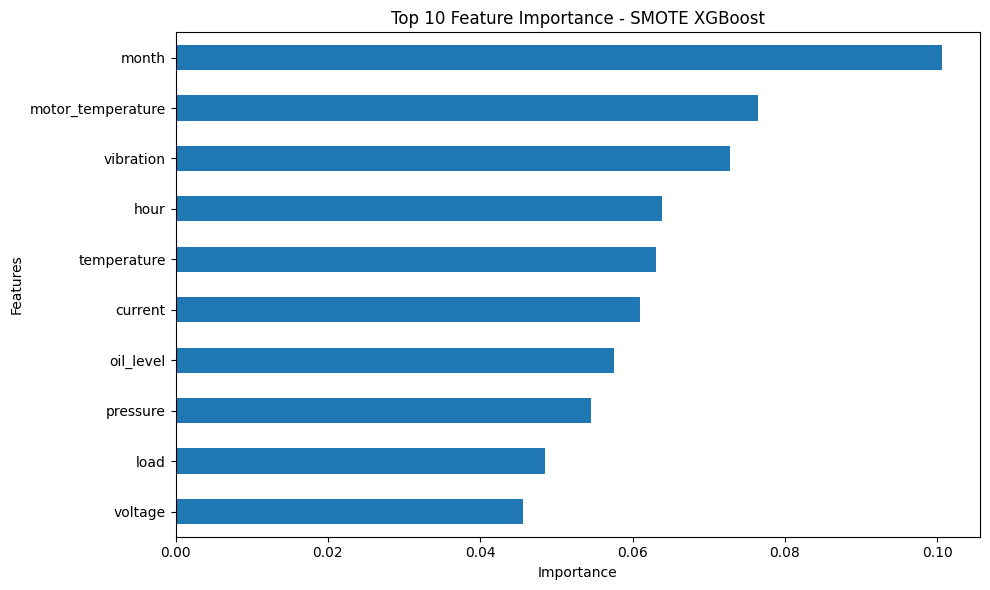

In [195]:
# ============================================================
# SECTION 40: SMOTE FEATURE IMPORTANCE
# ============================================================

importance_smote = pd.Series(
    xgb_smote.feature_importances_,
    index=X_train.columns
)

importance_smote = importance_smote.sort_values(
    ascending=False
)

print("\nTop 10 Important Features - SMOTE XGBoost:")
print(importance_smote.head(10))


# Plot feature importance
plt.figure(figsize=(10, 6))

importance_smote.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Feature Importance - SMOTE XGBoost")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [196]:
# ============================================================
# SECTION 41: XGBOOST HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

print("\n" + "="*60)
print("XGBOOST HYPERPARAMETER TUNING")
print("="*60)

# Base XGBoost model
xgb_tuning = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Parameters to search
param_grid = {
    "n_estimators": [50, 100, 150, 200, 300],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.15, 0.2],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=xgb_tuning,
    param_distributions=param_grid,
    n_iter=30,
    scoring="f1",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# IMPORTANT:
# Use the ORIGINAL training data here.
# We are NOT using the SMOTE data for this experiment.

random_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(random_search.best_score_)


XGBOOST HYPERPARAMETER TUNING
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters:
{'subsample': 0.7, 'n_estimators': 150, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.15, 'gamma': 0, 'colsample_bytree': 0.9}

Best Cross-Validation F1 Score:
0.341890190592761


In [197]:
# ============================================================
# SECTION 42: TEST TUNED XGBOOST
# ============================================================

best_xgb = random_search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test)

print("\n" + "="*60)
print("TUNED XGBOOST RESULTS")
print("="*60)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))


TUNED XGBOOST RESULTS

Confusion Matrix:
[[158  10]
 [ 24   8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       168
           1       0.44      0.25      0.32        32

    accuracy                           0.83       200
   macro avg       0.66      0.60      0.61       200
weighted avg       0.80      0.83      0.81       200



In [198]:
# ============================================================
# SECTION 43: THRESHOLD TUNING FOR TUNED XGBOOST
# ============================================================

from sklearn.metrics import f1_score

# Failure probabilities
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

best_threshold_tuned = 0.50
best_f1_tuned = 0

for threshold in [i / 100 for i in range(10, 91)]:

    y_pred_threshold = (
        y_prob_tuned >= threshold
    ).astype(int)

    f1 = f1_score(
        y_test,
        y_pred_threshold
    )

    if f1 > best_f1_tuned:
        best_f1_tuned = f1
        best_threshold_tuned = threshold

print("\nBest Threshold:", best_threshold_tuned)
print("Best F1:", best_f1_tuned)


# Final prediction using tuned threshold
y_pred_tuned_threshold = (
    y_prob_tuned >= best_threshold_tuned
).astype(int)

print("\nConfusion Matrix - Tuned Threshold:")
print(confusion_matrix(
    y_test,
    y_pred_tuned_threshold
))

print("\nClassification Report - Tuned Threshold:")
print(classification_report(
    y_test,
    y_pred_tuned_threshold
))


Best Threshold: 0.16
Best F1: 0.4878048780487805

Confusion Matrix - Tuned Threshold:
[[138  30]
 [ 12  20]]

Classification Report - Tuned Threshold:
              precision    recall  f1-score   support

           0       0.92      0.82      0.87       168
           1       0.40      0.62      0.49        32

    accuracy                           0.79       200
   macro avg       0.66      0.72      0.68       200
weighted avg       0.84      0.79      0.81       200



In [199]:
# ============================================================
# SECTION 44: LEAKAGE-FREE VALIDATION SET
# ============================================================

print("\n" + "="*60)
print("CREATING VALIDATION SET")
print("="*60)

# Split the original training data into:
# 80% actual training
# 20% validation

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("\nTraining data:", X_tr.shape)
print("Validation data:", X_val.shape)
print("Test data:", X_test.shape)

print("\nTraining class distribution:")
print(y_tr.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())


CREATING VALIDATION SET

Training data: (640, 19)
Validation data: (160, 19)
Test data: (200, 19)

Training class distribution:
machine_failure
0    536
1    104
Name: count, dtype: int64

Validation class distribution:
machine_failure
0    134
1     26
Name: count, dtype: int64


In [200]:
# ============================================================
# SECTION 45: LEAKAGE-FREE SMOTE XGBOOST
# ============================================================

print("\n" + "="*60)
print("LEAKAGE-FREE SMOTE XGBOOST")
print("="*60)

# Apply SMOTE ONLY to the training portion
smote_final = SMOTE(random_state=42)

X_tr_smote, y_tr_smote = smote_final.fit_resample(
    X_tr,
    y_tr
)

print("\nBefore SMOTE:")
print(y_tr.value_counts())

print("\nAfter SMOTE:")
print(y_tr_smote.value_counts())


# Train SMOTE XGBoost
xgb_smote_final = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_smote_final.fit(
    X_tr_smote,
    y_tr_smote
)

print("\nSMOTE XGBoost training completed.")


LEAKAGE-FREE SMOTE XGBOOST

Before SMOTE:
machine_failure
0    536
1    104
Name: count, dtype: int64

After SMOTE:
machine_failure
0    536
1    536
Name: count, dtype: int64

SMOTE XGBoost training completed.


In [201]:
# ============================================================
# SECTION 46: SMOTE THRESHOLD USING VALIDATION SET
# ============================================================

print("\n" + "="*60)
print("SMOTE THRESHOLD SELECTION")
print("="*60)

# Predict probabilities on VALIDATION data
y_val_prob_smote = xgb_smote_final.predict_proba(
    X_val
)[:, 1]

best_threshold_smote_final = 0.50
best_f1_smote_final = 0

# Search thresholds
for threshold in [i / 100 for i in range(10, 91)]:

    y_val_pred = (
        y_val_prob_smote >= threshold
    ).astype(int)

    f1 = f1_score(
        y_val,
        y_val_pred
    )

    if f1 > best_f1_smote_final:
        best_f1_smote_final = f1
        best_threshold_smote_final = threshold


print("\nBest Validation Threshold:",
      best_threshold_smote_final)

print("Validation F1:",
      round(best_f1_smote_final, 4))


SMOTE THRESHOLD SELECTION

Best Validation Threshold: 0.52
Validation F1: 0.4483


In [202]:
# ============================================================
# SECTION 47: FINAL SMOTE TEST EVALUATION
# ============================================================

print("\n" + "="*60)
print("FINAL SMOTE TEST RESULTS")
print("="*60)

# Predict probabilities on untouched TEST data
y_test_prob_smote = xgb_smote_final.predict_proba(
    X_test
)[:, 1]

# Apply the threshold selected using validation data
y_test_pred_smote_final = (
    y_test_prob_smote >= best_threshold_smote_final
).astype(int)

print("\nChosen Threshold:",
      best_threshold_smote_final)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_test_pred_smote_final
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_smote_final
    )
)


FINAL SMOTE TEST RESULTS

Chosen Threshold: 0.52

Confusion Matrix:
[[145  23]
 [ 22  10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       168
           1       0.30      0.31      0.31        32

    accuracy                           0.78       200
   macro avg       0.59      0.59      0.59       200
weighted avg       0.78      0.78      0.78       200



In [203]:
# ============================================================
# SECTION 48: LEAKAGE-FREE TUNED XGBOOST
# ============================================================

print("\n" + "="*60)
print("LEAKAGE-FREE TUNED XGBOOST")
print("="*60)

# Create a new model using the best parameters
best_xgb_final = XGBClassifier(
    **random_search.best_params_,
    random_state=42,
    eval_metric="logloss"
)

# Train ONLY on X_tr / y_tr
best_xgb_final.fit(
    X_tr,
    y_tr
)

print("\nTuned XGBoost training completed.")


LEAKAGE-FREE TUNED XGBOOST

Tuned XGBoost training completed.


In [204]:
# ============================================================
# SECTION 49: TUNED XGBOOST THRESHOLD
# ============================================================

print("\n" + "="*60)
print("TUNED XGBOOST THRESHOLD SELECTION")
print("="*60)

# Validation probabilities
y_val_prob_tuned = best_xgb_final.predict_proba(
    X_val
)[:, 1]

best_threshold_final = 0.50
best_f1_final = 0

for threshold in [i / 100 for i in range(10, 91)]:

    y_val_pred = (
        y_val_prob_tuned >= threshold
    ).astype(int)

    f1 = f1_score(
        y_val,
        y_val_pred
    )

    if f1 > best_f1_final:
        best_f1_final = f1
        best_threshold_final = threshold


print("\nBest Validation Threshold:",
      best_threshold_final)

print("Validation F1:",
      round(best_f1_final, 4))


TUNED XGBOOST THRESHOLD SELECTION

Best Validation Threshold: 0.49
Validation F1: 0.4651


In [205]:
# ============================================================
# SECTION 50: FINAL TUNED XGBOOST TEST
# ============================================================

print("\n" + "="*60)
print("FINAL TUNED XGBOOST TEST RESULTS")
print("="*60)

# Predict probabilities on untouched test set
y_test_prob_final = best_xgb_final.predict_proba(
    X_test
)[:, 1]

# Use threshold chosen ONLY from validation set
y_test_pred_final = (
    y_test_prob_final >= best_threshold_final
).astype(int)

print("\nChosen Threshold:",
      best_threshold_final)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_test_pred_final
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_final
    )
)


FINAL TUNED XGBOOST TEST RESULTS

Chosen Threshold: 0.49

Confusion Matrix:
[[156  12]
 [ 26   6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       168
           1       0.33      0.19      0.24        32

    accuracy                           0.81       200
   macro avg       0.60      0.56      0.57       200
weighted avg       0.77      0.81      0.79       200



In [206]:
# ============================================================
# SECTION 51: 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate

print("\n" + "="*60)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("="*60)

# Create 5 stratified folds
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Models to compare
cv_models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    )
}

# Evaluate each model
for name, model in cv_models.items():

    print("\n" + "-"*60)
    print(name)
    print("-"*60)

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring={
            "precision": "precision",
            "recall": "recall",
            "f1": "f1"
        },
        n_jobs=-1
    )

    print(
        "Precision: {:.3f} ± {:.3f}".format(
            scores["test_precision"].mean(),
            scores["test_precision"].std()
        )
    )

    print(
        "Recall:    {:.3f} ± {:.3f}".format(
            scores["test_recall"].mean(),
            scores["test_recall"].std()
        )
    )

    print(
        "F1 Score:  {:.3f} ± {:.3f}".format(
            scores["test_f1"].mean(),
            scores["test_f1"].std()
        )
    )


5-FOLD STRATIFIED CROSS-VALIDATION

------------------------------------------------------------
Logistic Regression
------------------------------------------------------------
Precision: 0.507 ± 0.255
Recall:    0.092 ± 0.052
F1 Score:  0.155 ± 0.085

------------------------------------------------------------
Random Forest
------------------------------------------------------------
Precision: 0.600 ± 0.374
Recall:    0.031 ± 0.015
F1 Score:  0.058 ± 0.029

------------------------------------------------------------
XGBoost
------------------------------------------------------------
Precision: 0.421 ± 0.077
Recall:    0.338 ± 0.038
F1 Score:  0.373 ± 0.045


In [207]:
# ============================================================
# SECTION 52: ANOMALY DETECTION - DATA PREPARATION
# ============================================================

from sklearn.ensemble import IsolationForest

print("\n" + "="*60)
print("ANOMALY DETECTION")
print("="*60)

# Use sensor features only
# We don't use machine_failure because anomaly detection
# should work independently of the failure label.

sensor_features = [
    "temperature",
    "vibration",
    "pressure",
    "humidity",
    "rotation_speed",
    "voltage",
    "current",
    "oil_level",
    "load",
    "motor_temperature",
    "gearbox_temperature",
    "sound_level",
    "fan_speed",
    "reactive_power",
    "active_power"
]

X_anomaly = df[sensor_features]

print("\nAnomaly detection features:")
print(sensor_features)

print("\nAnomaly detection data shape:")
print(X_anomaly.shape)


ANOMALY DETECTION

Anomaly detection features:
['temperature', 'vibration', 'pressure', 'humidity', 'rotation_speed', 'voltage', 'current', 'oil_level', 'load', 'motor_temperature', 'gearbox_temperature', 'sound_level', 'fan_speed', 'reactive_power', 'active_power']

Anomaly detection data shape:
(1000, 15)


In [208]:
# ============================================================
# SECTION 53: TRAIN ISOLATION FOREST
# ============================================================

print("\n" + "="*60)
print("TRAINING ISOLATION FOREST")
print("="*60)

isolation_forest = IsolationForest(
    n_estimators=100,
    contamination=0.10,
    random_state=42
)

# Train the anomaly detection model
isolation_forest.fit(X_anomaly)

print("\nIsolation Forest training completed.")


TRAINING ISOLATION FOREST

Isolation Forest training completed.


In [209]:
# ============================================================
# SECTION 54: DETECT ANOMALIES
# ============================================================

# Isolation Forest returns:
#  1  = normal
# -1  = anomaly

anomaly_prediction = isolation_forest.predict(X_anomaly)

# Convert result to easier labels
df["anomaly"] = anomaly_prediction

df["anomaly_label"] = df["anomaly"].map({
    1: "NORMAL",
    -1: "ANOMALY"
})

print("\nAnomaly counts:")
print(df["anomaly_label"].value_counts())


Anomaly counts:
anomaly_label
NORMAL     900
ANOMALY    100
Name: count, dtype: int64


In [210]:
# ============================================================
# SECTION 55: ANOMALY SCORE
# ============================================================

anomaly_scores = isolation_forest.decision_function(
    X_anomaly
)

df["anomaly_score"] = anomaly_scores

print("\nFirst 10 anomaly scores:")
print(df["anomaly_score"].head(10))


First 10 anomaly scores:
0    0.049859
1    0.054692
2    0.037071
3    0.043196
4    0.014365
5    0.076155
6    0.026354
7    0.034600
8    0.071165
9    0.055949
Name: anomaly_score, dtype: float64


In [211]:
# ============================================================
# SECTION 56: SHOW ANOMALOUS READINGS
# ============================================================

anomalies = df[
    df["anomaly_label"] == "ANOMALY"
]

print("\n" + "="*60)
print("ANOMALOUS SENSOR READINGS")
print("="*60)

print(
    anomalies[
        sensor_features + ["machine_failure", "anomaly_score"]
    ].head(10)
)


ANOMALOUS SENSOR READINGS
     temperature  vibration   pressure   humidity  rotation_speed     voltage  \
16     69.935844   0.434858  29.206455  32.403270     1475.958311  198.952505   
22     75.337641   0.497565  34.081976  37.942867     1407.407863  218.140755   
24     72.278086   0.672754  20.941464  30.651291     1466.067847  242.770865   
33     69.711445   0.564720  31.516410  35.088530     1358.046067  225.384350   
35     68.895782   0.657399  38.278980  42.234363     1547.835159  243.943619   
74     61.901274   0.599627  28.147044  36.334835     1477.702814  222.008451   
100    67.923146   0.599801  31.129229  36.465537     1424.988907  230.287690   
106    84.430930   0.561277  27.298138  33.534292     1485.287875  209.700277   
120    78.955160   0.610553  37.237846  37.582193     1469.617683  206.194013   
127    72.168511   0.424572  33.342965  46.591512     1589.936251  219.857296   

      current  oil_level       load  motor_temperature  gearbox_temperature  \
16

In [212]:
# ============================================================
# SECTION 57: ANOMALY VS ACTUAL FAILURE
# ============================================================

print("\n" + "="*60)
print("ANOMALY VS MACHINE FAILURE")
print("="*60)

comparison = pd.crosstab(
    df["anomaly_label"],
    df["machine_failure"]
)

print(comparison)


ANOMALY VS MACHINE FAILURE
machine_failure    0    1
anomaly_label            
ANOMALY           78   22
NORMAL           760  140


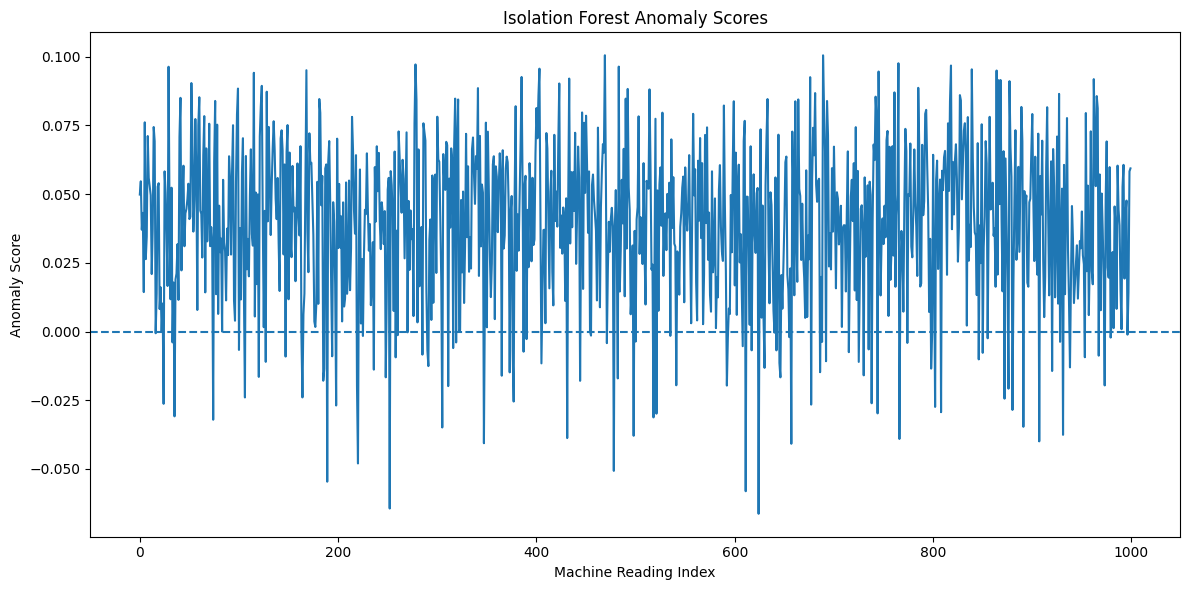

In [213]:
# ============================================================
# SECTION 58: ANOMALY SCORE VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df["anomaly_score"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Isolation Forest Anomaly Scores")
plt.xlabel("Machine Reading Index")
plt.ylabel("Anomaly Score")

plt.tight_layout()
plt.show()

In [214]:
# ============================================================
# SECTION 59: ISOLATION FOREST - NORMAL OPERATION MODEL
# ============================================================

print("\n" + "="*60)
print("ISOLATION FOREST - NORMAL OPERATION")
print("="*60)

# Use only machines that did NOT fail
normal_data = df[df["machine_failure"] == 0]

X_normal = normal_data[sensor_features]

print("\nNormal training data shape:")
print(X_normal.shape)

# Create Isolation Forest
isolation_forest_normal = IsolationForest(
    n_estimators=100,
    contamination=0.10,
    random_state=42
)

# Train only on normal machine behavior
isolation_forest_normal.fit(X_normal)

print("\nIsolation Forest trained on normal operation.")


ISOLATION FOREST - NORMAL OPERATION

Normal training data shape:
(838, 15)

Isolation Forest trained on normal operation.


In [215]:
# ============================================================
# SECTION 60: DETECT ANOMALIES
# ============================================================

# Calculate anomaly predictions
normal_model_prediction = isolation_forest_normal.predict(
    X_anomaly
)

# Convert to readable labels
df["anomaly_normal_model"] = normal_model_prediction

df["anomaly_normal_label"] = df[
    "anomaly_normal_model"
].map({
    1: "NORMAL",
    -1: "ANOMALY"
})

print("\nAnomaly counts:")
print(
    df["anomaly_normal_label"].value_counts()
)


Anomaly counts:
anomaly_normal_label
NORMAL     891
ANOMALY    109
Name: count, dtype: int64


In [216]:
# ============================================================
# SECTION 61: ANOMALY SCORE
# ============================================================

normal_anomaly_score = (
    isolation_forest_normal
    .decision_function(X_anomaly)
)

df["normal_anomaly_score"] = normal_anomaly_score

print("\nFirst 10 anomaly scores:")
print(
    df["normal_anomaly_score"].head(10)
)


First 10 anomaly scores:
0    0.050667
1    0.064252
2    0.015156
3    0.060079
4    0.013231
5    0.072873
6    0.040005
7    0.024503
8    0.069739
9    0.053915
Name: normal_anomaly_score, dtype: float64


In [217]:
# ============================================================
# SECTION 62: ANOMALY VS MACHINE FAILURE
# ============================================================

print("\n" + "="*60)
print("NORMAL MODEL: ANOMALY VS MACHINE FAILURE")
print("="*60)

comparison_normal = pd.crosstab(
    df["anomaly_normal_label"],
    df["machine_failure"]
)

print(comparison_normal)


NORMAL MODEL: ANOMALY VS MACHINE FAILURE
machine_failure         0    1
anomaly_normal_label          
ANOMALY                84   25
NORMAL                754  137


In [218]:
# ============================================================
# SECTION 63: ANOMALY DETECTION STATISTICS
# ============================================================

anomaly_mask = (
    df["anomaly_normal_label"] == "ANOMALY"
)

failure_mask = (
    df["machine_failure"] == 1
)

# How many actual failures were detected as anomalies?
failure_anomalies = (
    anomaly_mask & failure_mask
).sum()

total_failures = failure_mask.sum()

# How many anomalies were actually failures?
total_anomalies = anomaly_mask.sum()

precision_anomaly = (
    failure_anomalies / total_anomalies
    if total_anomalies > 0 else 0
)

recall_anomaly = (
    failure_anomalies / total_failures
    if total_failures > 0 else 0
)

print("\nTotal anomalies:", total_anomalies)

print(
    "Failures detected as anomalies:",
    failure_anomalies
)

print(
    "Anomaly precision:",
    round(precision_anomaly, 3)
)

print(
    "Anomaly recall:",
    round(recall_anomaly, 3)
)


Total anomalies: 109
Failures detected as anomalies: 25
Anomaly precision: 0.229
Anomaly recall: 0.154


In [219]:
# ============================================================
# SECTION 64: PROCESS OPTIMIZATION - WHAT-IF SIMULATOR
# ============================================================

print("\n" + "="*60)
print("PROCESS OPTIMIZATION - WHAT-IF SIMULATOR")
print("="*60)

# Use the leakage-free tuned XGBoost model
optimization_model = best_xgb_final

# Use the threshold selected using validation data
optimization_threshold = best_threshold_final


# ------------------------------------------------------------
# Function to calculate failure probability
# ------------------------------------------------------------

def calculate_failure_probability(sensor_data):

    input_data = pd.DataFrame([sensor_data])

    # Make sure columns are in exactly the same order
    # used during model training
    input_data = input_data[X_train.columns]

    probability = optimization_model.predict_proba(
        input_data
    )[0][1]

    return probability


PROCESS OPTIMIZATION - WHAT-IF SIMULATOR


In [221]:
# ============================================================
# SECTION 65: CREATE WHAT-IF SCENARIO
# ============================================================

# Take one machine reading from the dataset

original_row = df.iloc[120].copy()

# Create a dictionary using the model features
current_condition = {}

for feature in X_train.columns:
    current_condition[feature] = original_row[feature]

# Calculate current failure probability
current_probability = calculate_failure_probability(
    current_condition
)

print("\nCurrent Machine Condition")
print("-------------------------")

print("Temperature:",
      current_condition["temperature"])

print("Vibration:",
      current_condition["vibration"])

print("Load:",
      current_condition["load"])

print(
    "\nCurrent Failure Probability:",
    round(current_probability * 100, 2),
    "%"
)


Current Machine Condition
-------------------------
Temperature: 78.95515974
Vibration: 0.610552593
Load: 91.40250553

Current Failure Probability: 87.54 %


In [223]:
# ============================================================
# SECTION 66: TEST DIFFERENT OPERATING CONDITIONS
# ============================================================

scenarios = []

# Scenario 1 - Current condition
scenario_1 = current_condition.copy()

scenarios.append({
    "Scenario": "Current",
    "Temperature": scenario_1["temperature"],
    "Vibration": scenario_1["vibration"],
    "Load": scenario_1["load"],
    "Failure Probability":
        calculate_failure_probability(scenario_1)
})


# Scenario 2 - Reduce load
scenario_2 = current_condition.copy()

scenario_2["load"] = scenario_2["load"] * 0.90

scenarios.append({
    "Scenario": "Reduce Load 10%",
    "Temperature": scenario_2["temperature"],
    "Vibration": scenario_2["vibration"],
    "Load": scenario_2["load"],
    "Failure Probability":
        calculate_failure_probability(scenario_2)
})


# Scenario 3 - Reduce temperature
scenario_3 = current_condition.copy()

scenario_3["temperature"] = (
    scenario_3["temperature"] - 5
)

scenarios.append({
    "Scenario": "Reduce Temperature 5",
    "Temperature": scenario_3["temperature"],
    "Vibration": scenario_3["vibration"],
    "Load": scenario_3["load"],
    "Failure Probability":
        calculate_failure_probability(scenario_3)
})


# Scenario 4 - Reduce vibration
scenario_4 = current_condition.copy()

scenario_4["vibration"] = (
    scenario_4["vibration"] * 0.90
)

scenarios.append({
    "Scenario": "Reduce Vibration 10%",
    "Temperature": scenario_4["temperature"],
    "Vibration": scenario_4["vibration"],
    "Load": scenario_4["load"],
    "Failure Probability":
        calculate_failure_probability(scenario_4)
})


# Scenario 5 - Combined improvement
scenario_5 = current_condition.copy()

scenario_5["load"] = (
    scenario_5["load"] * 0.90
)

scenario_5["temperature"] = (
    scenario_5["temperature"] - 5
)

scenario_5["vibration"] = (
    scenario_5["vibration"] * 0.90
)

scenarios.append({
    "Scenario": "Combined Improvement",
    "Temperature": scenario_5["temperature"],
    "Vibration": scenario_5["vibration"],
    "Load": scenario_5["load"],
    "Failure Probability":
        calculate_failure_probability(scenario_5)
})

In [224]:
# ============================================================
# SECTION 67: WHAT-IF RESULTS
# ============================================================

optimization_results = pd.DataFrame(scenarios)

# Convert probability to percentage
optimization_results[
    "Failure Probability"
] = (
    optimization_results["Failure Probability"] * 100
)

print("\n" + "="*60)
print("WHAT-IF OPTIMIZATION RESULTS")
print("="*60)

print(
    optimization_results.to_string(
        index=False
    )
)


WHAT-IF OPTIMIZATION RESULTS
            Scenario  Temperature  Vibration      Load  Failure Probability
             Current     78.95516   0.610553 91.402506            87.539284
     Reduce Load 10%     78.95516   0.610553 82.262255            36.480659
Reduce Temperature 5     73.95516   0.610553 91.402506            72.915047
Reduce Vibration 10%     78.95516   0.549497 91.402506            62.458904
Combined Improvement     73.95516   0.549497 82.262255             3.146981


In [225]:
# ============================================================
# SECTION 68: BEST OPERATING SCENARIO
# ============================================================

best_scenario = optimization_results.loc[
    optimization_results["Failure Probability"].idxmin()
]

print("\n" + "="*60)
print("RECOMMENDED OPERATING CONDITION")
print("="*60)

print(
    "\nRecommended Scenario:",
    best_scenario["Scenario"]
)

print(
    "Predicted Failure Probability:",
    round(
        best_scenario["Failure Probability"],
        2
    ),
    "%"
)


RECOMMENDED OPERATING CONDITION

Recommended Scenario: Combined Improvement
Predicted Failure Probability: 3.15 %


In [226]:
# ============================================================
# SECTION 69: OPTIMIZATION IMPROVEMENT
# ============================================================

original_probability = optimization_results[
    optimization_results["Scenario"] == "Current"
]["Failure Probability"].iloc[0]

best_probability = best_scenario[
    "Failure Probability"
]

improvement = (
    original_probability - best_probability
)

print("\n" + "="*60)
print("PROCESS OPTIMIZATION IMPROVEMENT")
print("="*60)

print(
    "\nOriginal Failure Probability:",
    round(original_probability, 2),
    "%"
)

print(
    "Optimized Failure Probability:",
    round(best_probability, 2),
    "%"
)

print(
    "Predicted Reduction:",
    round(improvement, 2),
    "percentage points"
)


PROCESS OPTIMIZATION IMPROVEMENT

Original Failure Probability: 87.54 %
Optimized Failure Probability: 3.15 %
Predicted Reduction: 84.39 percentage points


In [227]:
# ============================================================
# SECTION 70: CONSTRAINED WHAT-IF OPTIMIZATION
# ============================================================

print("\n" + "="*60)
print("CONSTRAINED WHAT-IF OPTIMIZATION")
print("="*60)

# Get minimum and maximum values from the original dataset
temperature_min = df["temperature"].min()
temperature_max = df["temperature"].max()

vibration_min = df["vibration"].min()
vibration_max = df["vibration"].max()

load_min = df["load"].min()
load_max = df["load"].max()

print("\nAllowed ranges from dataset:")
print("Temperature:", round(temperature_min, 2), "to", round(temperature_max, 2))
print("Vibration:  ", round(vibration_min, 2), "to", round(vibration_max, 2))
print("Load:       ", round(load_min, 2), "to", round(load_max, 2))


# ------------------------------------------------------------
# Generate realistic small changes
# ------------------------------------------------------------

optimization_scenarios = []

load_changes = [0, -0.05, -0.10]
temperature_changes = [0, -2, -5]
vibration_changes = [0, -0.05, -0.10]


for load_change in load_changes:

    for temperature_change in temperature_changes:

        for vibration_change in vibration_changes:

            scenario = current_condition.copy()

            # Apply changes
            scenario["load"] = (
                current_condition["load"]
                * (1 + load_change)
            )

            scenario["temperature"] = (
                current_condition["temperature"]
                + temperature_change
            )

            scenario["vibration"] = (
                current_condition["vibration"]
                * (1 + vibration_change)
            )

            # Check that values remain inside dataset range
            if not (
                load_min <= scenario["load"] <= load_max
                and temperature_min <= scenario["temperature"] <= temperature_max
                and vibration_min <= scenario["vibration"] <= vibration_max
            ):
                continue

            probability = calculate_failure_probability(
                scenario
            )

            optimization_scenarios.append({
                "Load Change": load_change * 100,
                "Temperature Change": temperature_change,
                "Vibration Change": vibration_change * 100,
                "Temperature": scenario["temperature"],
                "Vibration": scenario["vibration"],
                "Load": scenario["load"],
                "Failure Probability": probability * 100
            })


# Convert to DataFrame
constrained_results = pd.DataFrame(
    optimization_scenarios
)

# Sort by lowest predicted failure probability
constrained_results = constrained_results.sort_values(
    by="Failure Probability"
)

print("\nTop 10 lowest-risk scenarios:")
print(
    constrained_results.head(10).to_string(
        index=False
    )
)


CONSTRAINED WHAT-IF OPTIMIZATION

Allowed ranges from dataset:
Temperature: 58.79 to 94.26
Vibration:   0.21 to 0.82
Load:        41.63 to 113.77

Top 10 lowest-risk scenarios:
 Load Change  Temperature Change  Vibration Change  Temperature  Vibration      Load  Failure Probability
        -5.0                  -5             -10.0     73.95516   0.549497 86.832380             2.793629
       -10.0                  -5             -10.0     73.95516   0.549497 82.262255             3.146981
        -5.0                  -5              -5.0     73.95516   0.580025 86.832380             5.162122
       -10.0                  -5              -5.0     73.95516   0.580025 82.262255             5.797187
        -5.0                  -2             -10.0     76.95516   0.549497 86.832380             6.798030
        -5.0                   0             -10.0     78.95516   0.549497 86.832380             7.251626
       -10.0                  -2             -10.0     76.95516   0.549497 82.26

In [228]:
# ============================================================
# SECTION 71: BEST CONSTRAINED SCENARIO
# ============================================================

best_constrained = constrained_results.iloc[0]

print("\n" + "="*60)
print("BEST CONSTRAINED OPERATING CONDITION")
print("="*60)

print(
    "\nLoad change:",
    best_constrained["Load Change"],
    "%"
)

print(
    "Temperature change:",
    best_constrained["Temperature Change"]
)

print(
    "Vibration change:",
    best_constrained["Vibration Change"],
    "%"
)

print(
    "\nPredicted Failure Probability:",
    round(
        best_constrained["Failure Probability"],
        2
    ),
    "%"
)


BEST CONSTRAINED OPERATING CONDITION

Load change: -5.0 %
Temperature change: -5.0
Vibration change: -10.0 %

Predicted Failure Probability: 2.79 %


In [229]:
# ============================================================
# SECTION 72: SAVE MODEL FEATURES
# ============================================================

joblib.dump(
    X_train.columns.tolist(),
    "feature_columns.pkl"
)

print("\nFeature columns saved successfully.")


Feature columns saved successfully.
